In [1]:
from sklearn.datasets import load_iris
iris_data = load_iris()
X = iris_data['data']

In [2]:
X.shape

(150, 4)

In [4]:
from sklearn.neighbors import LocalOutlierFactor

In [5]:
lof = LocalOutlierFactor(n_neighbors = 2)

In [6]:
lof

LocalOutlierFactor(n_neighbors=2)

In [7]:
anomaly_predictions = lof.fit_predict(X)
print(anomaly_predictions)

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1
 -1  1  1  1  1  1  1 -1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1 -1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1 -1  1 -1 -1  1  1  1  1 -1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1]


In [8]:
len(anomaly_predictions)

150

anomaly_predictions = lof.fit_predict(X): This line fits the LOF model to the data X and simultaneously predicts the anomaly score for each data point. 

The fit_predict method returns an array of anomaly predictions:
- 1 indicates that the data point is likely an inlier (normal).
- -1 indicates that the data point is likely an outlier (anomalous).

In [9]:
print(sum(anomaly_predictions==-1))

15


**Following is the scatter plot of the attribute 1 and 2 with predicted inliers and outliers**

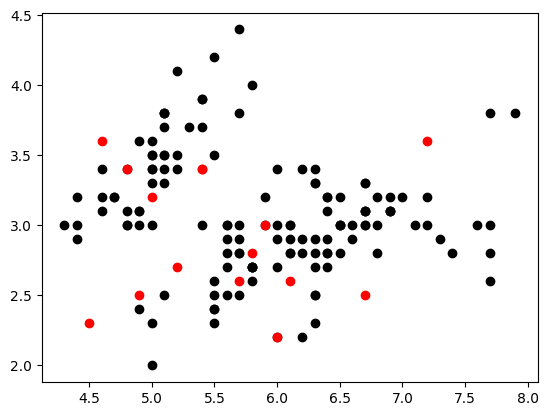

In [10]:
import matplotlib.pyplot as plt
plt.scatter(X[anomaly_predictions == 1, 0], X[anomaly_predictions ==1, 1], c='k')
plt.scatter(X[anomaly_predictions == -1, 0], X[anomaly_predictions ==-1, 1], c='r')

**Following is the scatter plot of the attribute 2 and 3 with predicted inliers and outliers**

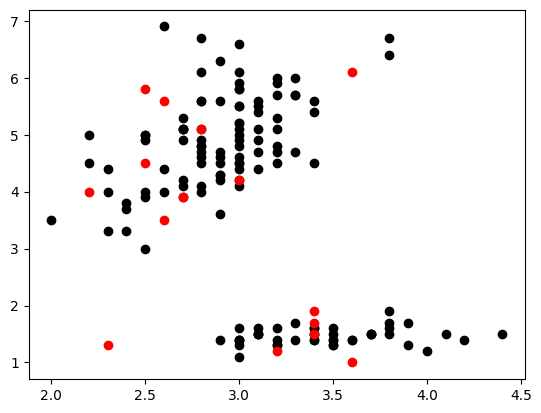

In [11]:
plt.scatter(X[anomaly_predictions == 1, 1], X[anomaly_predictions ==1, 2], c='k')
plt.scatter(X[anomaly_predictions == -1, 1], X[anomaly_predictions ==-1, 2], c='r')

**Following is the scatter plot of the attribute 3 and 4 with predicted inliers and outliers**

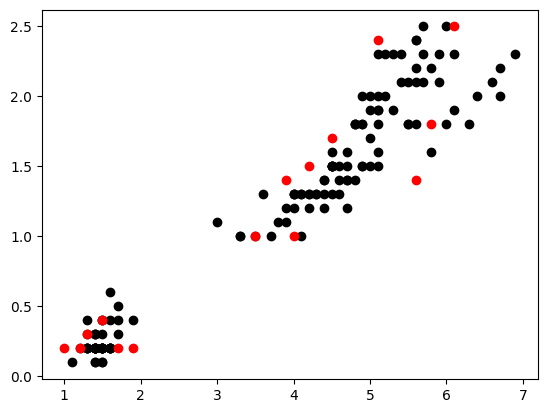

In [12]:
plt.scatter(X[anomaly_predictions == 1, 2], X[anomaly_predictions ==1, 3], c='k')
plt.scatter(X[anomaly_predictions == -1, 2], X[anomaly_predictions ==-1, 3], c='r')

In [15]:
lof = LocalOutlierFactor(n_neighbors = 10)
anomaly_predictions = lof.fit_predict(X)
print(anomaly_predictions)

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1 -1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1 -1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1]


In [16]:
print(sum(anomaly_predictions==-1))

5


In [17]:
print(lof.negative_outlier_factor_)
# Scikit-Learn scales it as a negative value for consistency with other tools (where "higher is better").

[-0.97491833 -0.99335874 -0.99815729 -1.00824782 -0.9976917  -1.11717439
 -1.11370626 -0.97592941 -1.22584809 -0.97719664 -1.05051871 -1.03968608
 -0.96819378 -1.46845779 -1.43580942 -1.60705599 -1.16844729 -0.9724836
 -1.25382907 -1.02774552 -1.14184381 -0.99930607 -1.65280127 -1.21861055
 -1.3304879  -1.07520579 -1.01479979 -0.98481089 -0.98477627 -0.95485991
 -0.97864179 -1.1052521  -1.25805279 -1.3292011  -0.97719664 -1.05613178
 -1.15059638 -1.00530932 -1.17758955 -0.96940699 -0.96919671 -2.14018923
 -1.16476524 -1.27993865 -1.27718985 -0.96819378 -1.10236725 -1.00355815
 -1.02243479 -0.97679204 -1.09877597 -0.99089701 -1.09808813 -1.05686223
 -0.96277141 -1.01422794 -0.98769249 -1.46497505 -0.99710081 -1.12895654
 -1.46087319 -1.00069535 -1.19113716 -0.97873484 -1.13546933 -1.02627471
 -1.04073803 -0.96110337 -1.28022616 -1.03139416 -1.05578741 -1.02622005
 -1.0359747  -0.98714535 -0.99734288 -1.00610864 -1.04263129 -1.01158531
 -0.99534778 -1.1887348  -1.07297441 -1.08992905 -0.

prints the negative outlier factor for each data point. 

The negative outlier factor is a score that indicates the degree to which a data point is an outlier. 
- Higher (less negative) values indicate that the point has a density similar to its neighbors
- Lower (more negative) values indicate that the point has a significantly lower density than its neighbors, thus suggesting it's an outlier.

**Scikit-Learn scales it as a negative value for consistency with other tools (where "higher is better").**

In [18]:
lof.offset_

-1.5

**This is the default offset value which is compared against the LOF value of each point. If LOF value is less than this offset value, it will be marked as an outlier.**

In [19]:
lof = LocalOutlierFactor(n_neighbors = 10, contamination=0.1)
anomaly_predictions = lof.fit_predict(X)
print(anomaly_predictions)

[ 1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1  1  1  1  1  1  1 -1  1
 -1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1  1 -1 -1  1  1  1
  1  1  1  1  1  1  1  1  1 -1  1  1 -1  1  1  1  1  1  1  1 -1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1
  1  1 -1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1]


In [20]:
print(sum(anomaly_predictions==-1))

15


In [21]:
lof.offset_

np.float64(-1.2762174320959443)

Offset used to obtain binary labels from the raw scores. Observations having a negative_outlier_factor smaller than offset_ are detected as abnormal. The offset is set to -1.5 (inliers score around -1), except when a contamination parameter different than “auto” is provided. In that case, the offset is defined in such a way we obtain the expected number of outliers in training.

**Let's work on a real-world dataset**

**We are going to use LOF and DBSCAN to predict the outliers**

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Loading the California Housing Dataset
california_housing = fetch_california_housing()
data = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
data.info()
X = data
y = california_housing.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled
print(type(X_scaled))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB
<class 'numpy.ndarray'>


In [23]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20)
outliers_lof = lof.fit_predict(X_scaled)
X_lof = X_scaled[outliers_lof == 1]
y_lof = y[outliers_lof == 1]
print(sum(outliers_lof==-1))

358


In [24]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=3, min_samples=2)
outliers_dbscan = dbscan.fit_predict(X_scaled)
X_dbscan = X_scaled[outliers_dbscan != -1]
y_dbscan = y[outliers_dbscan != -1]
print(sum(outliers_dbscan==-1))

18


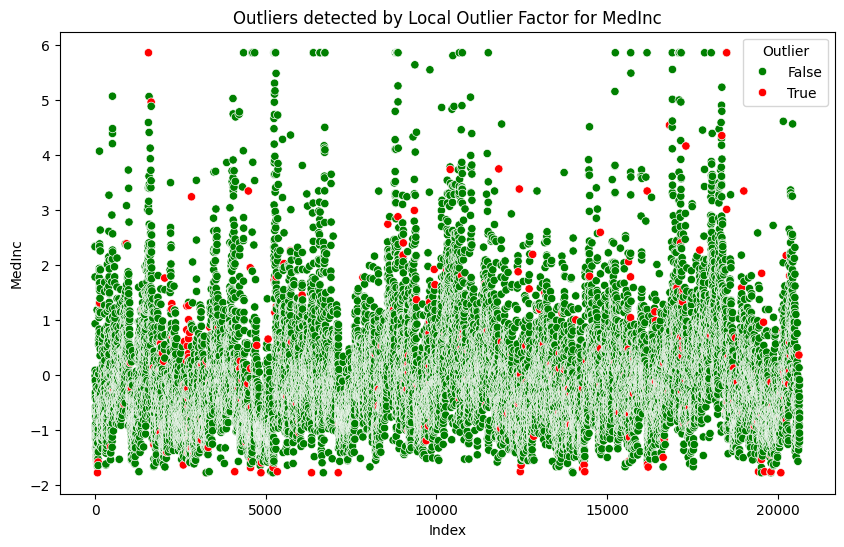

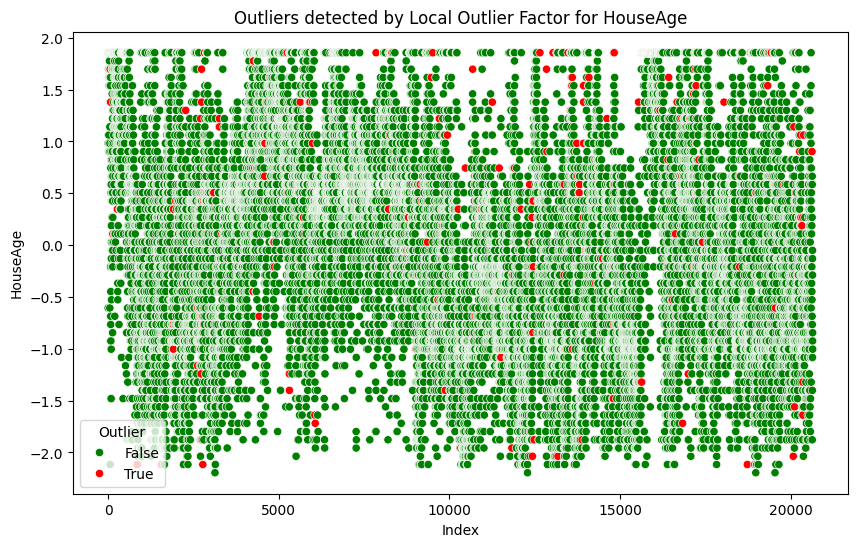

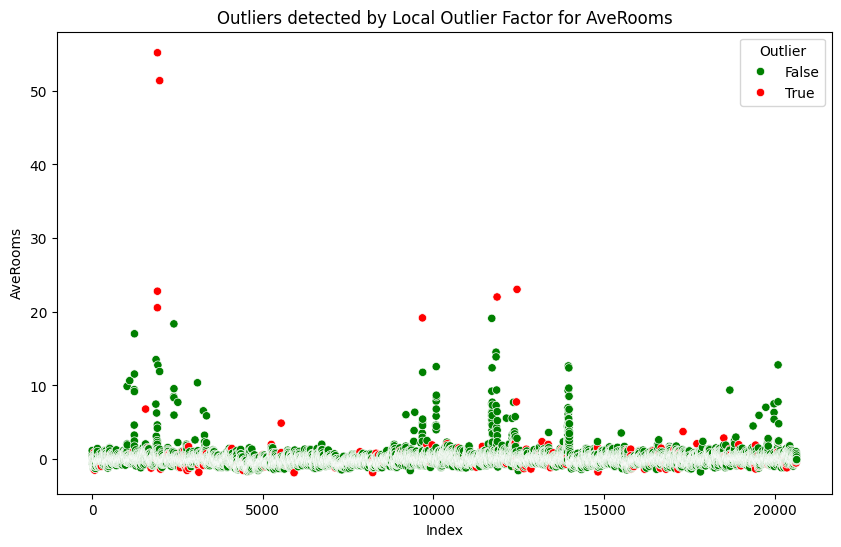

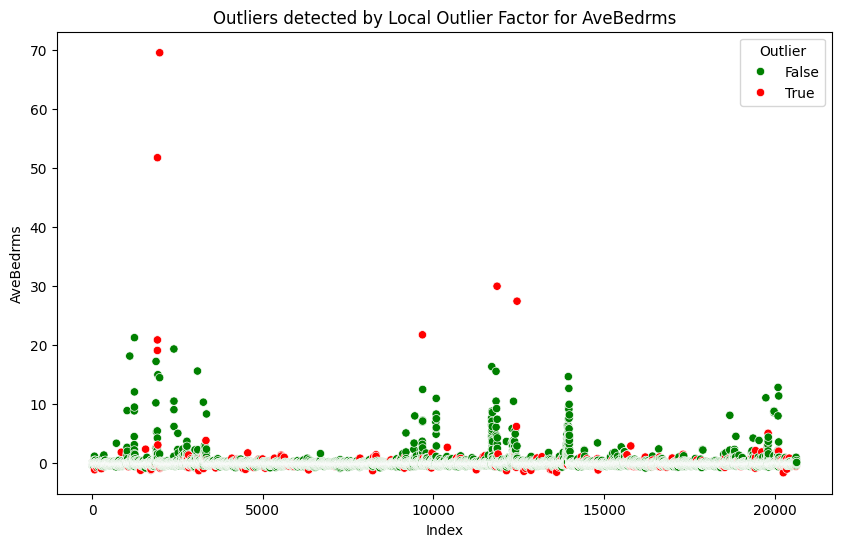

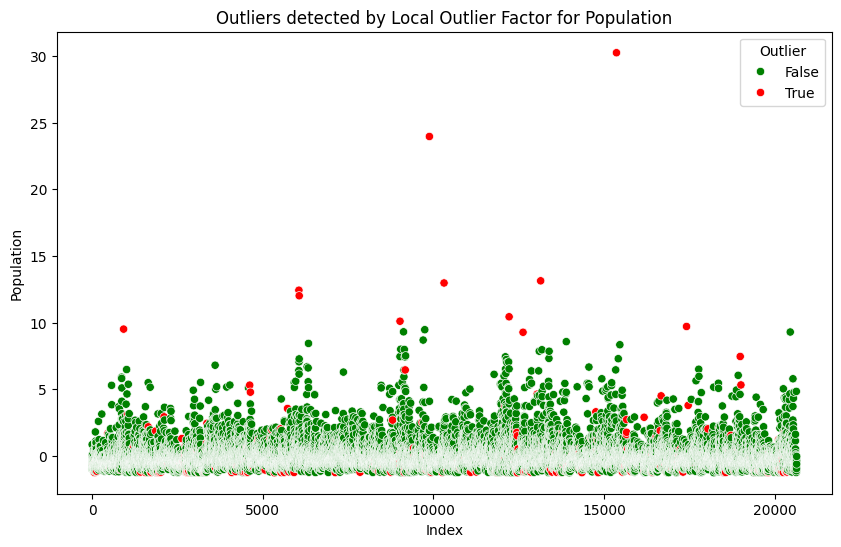

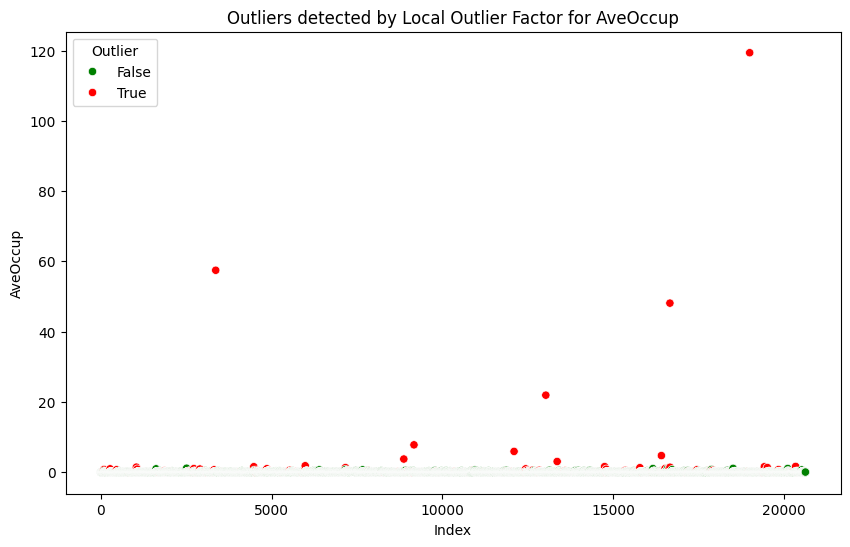

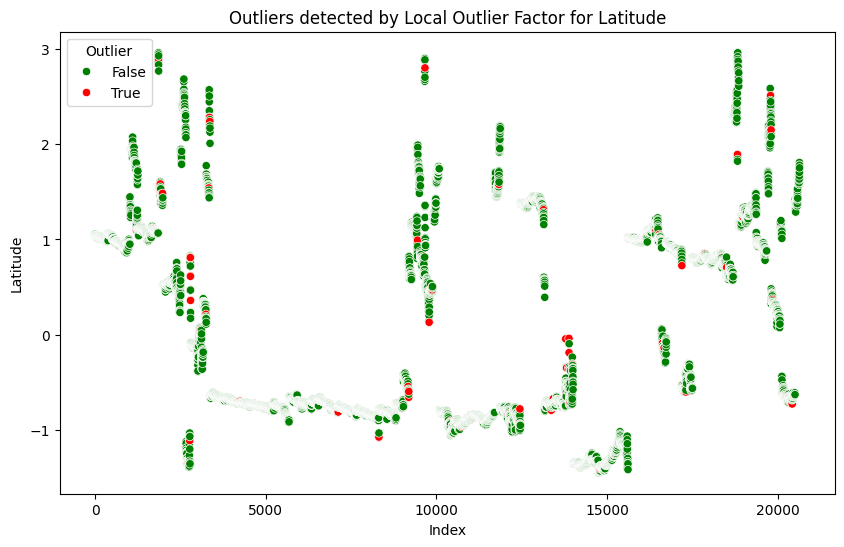

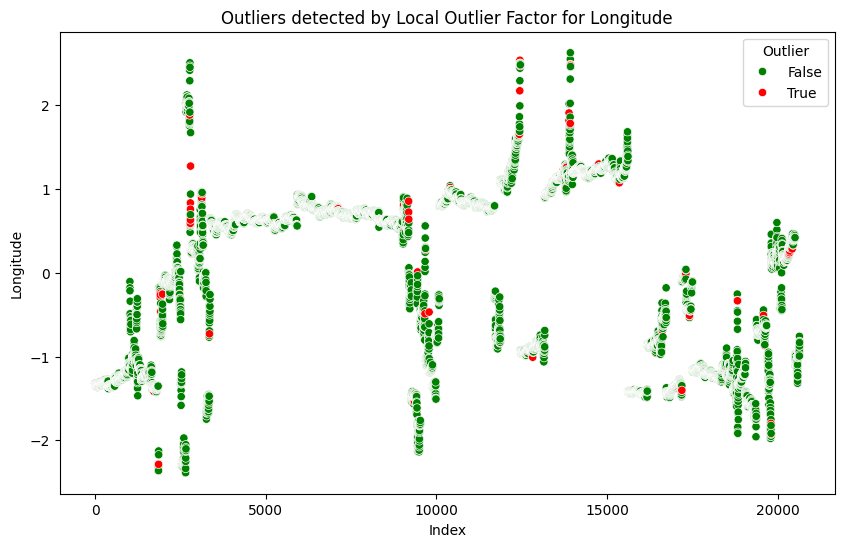

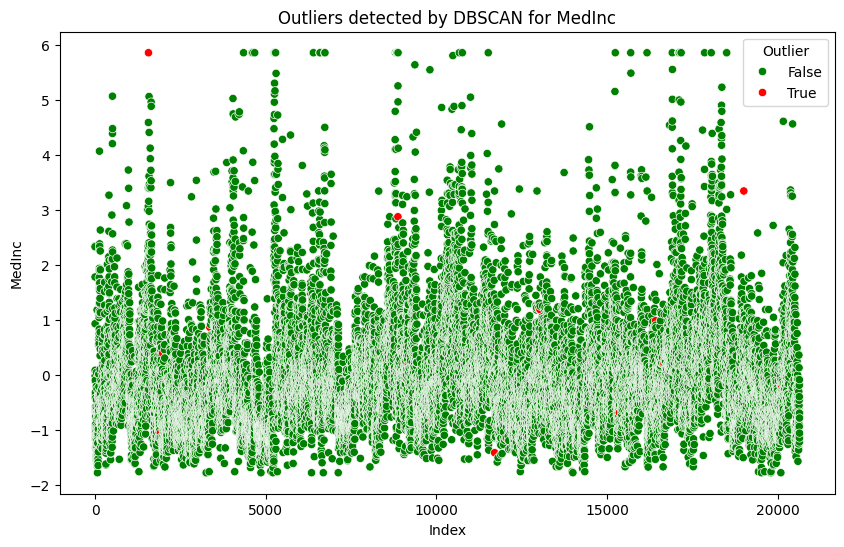

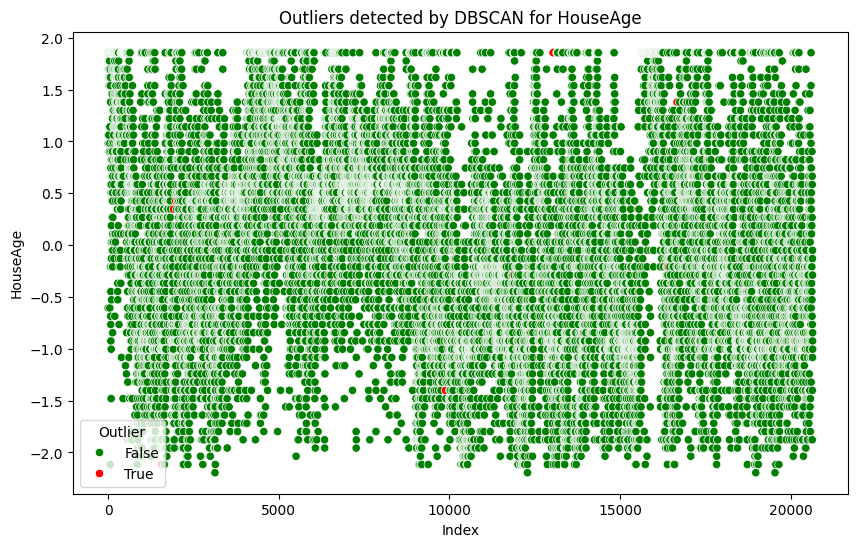

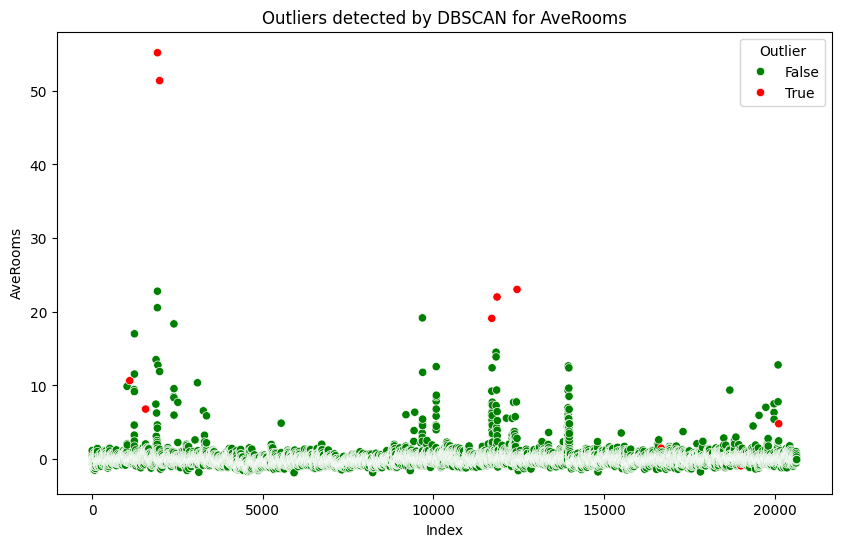

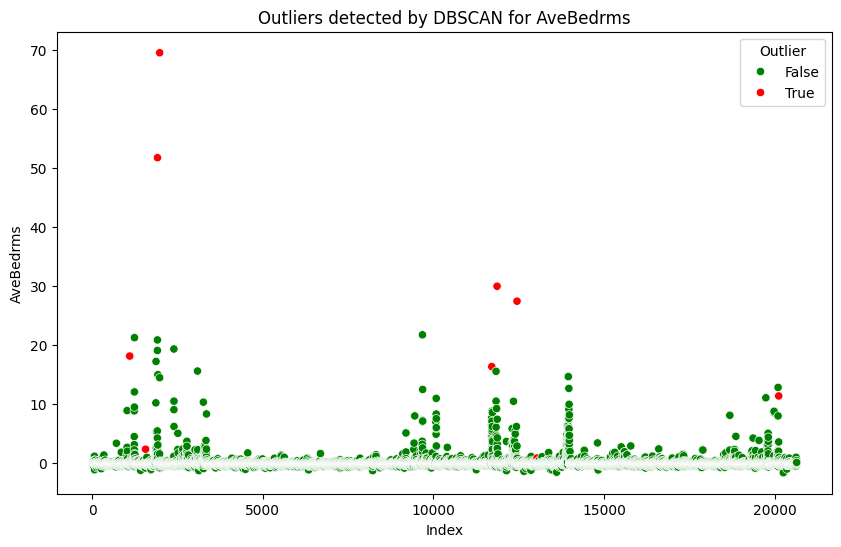

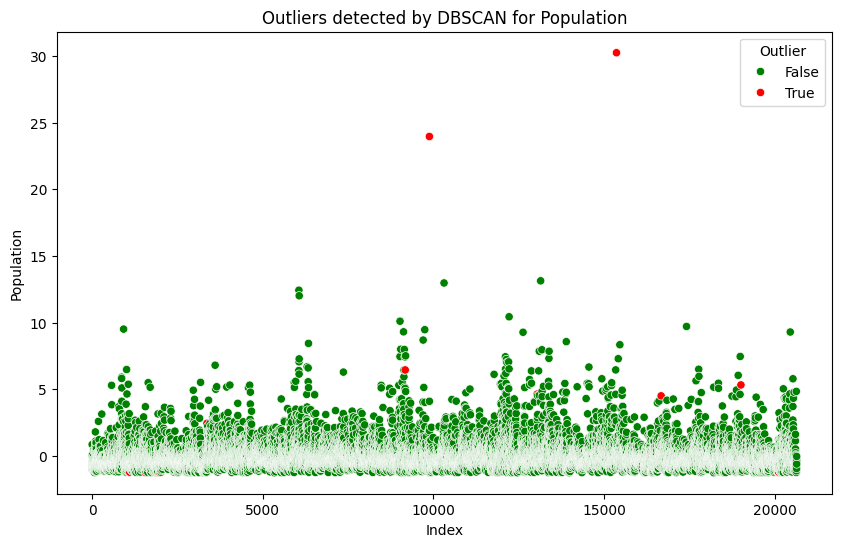

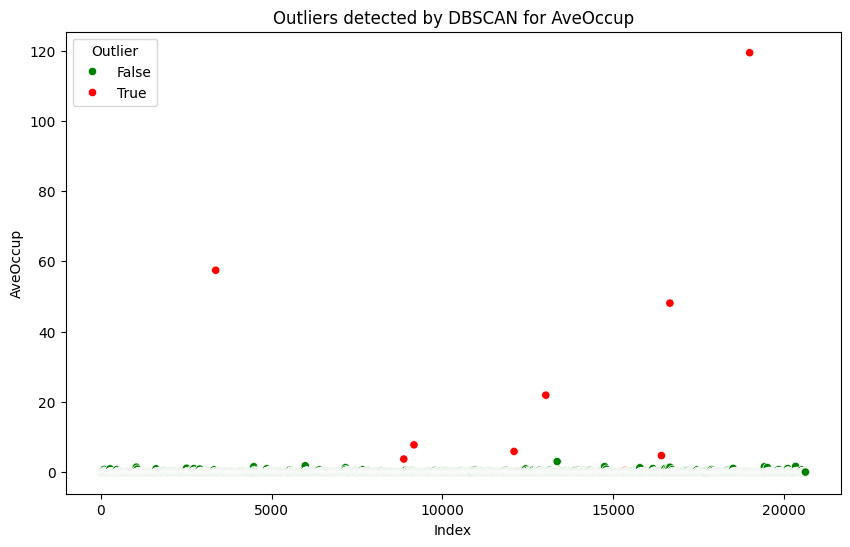

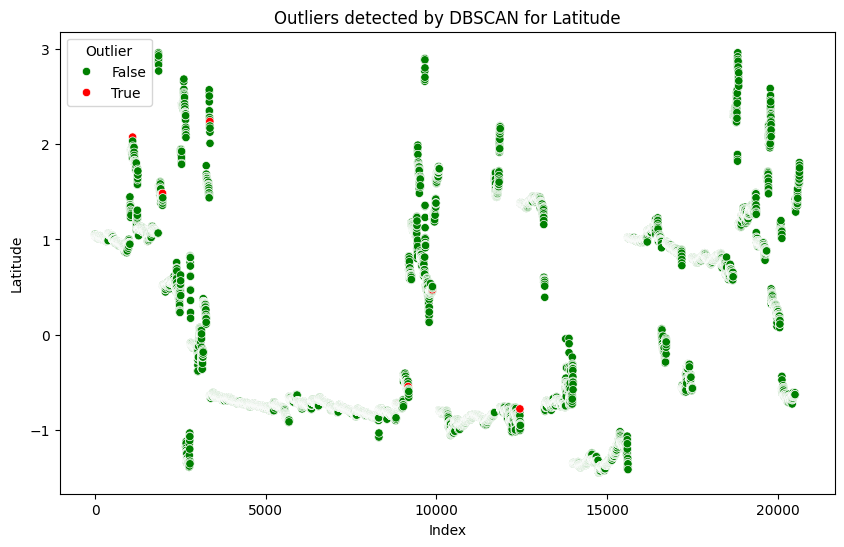

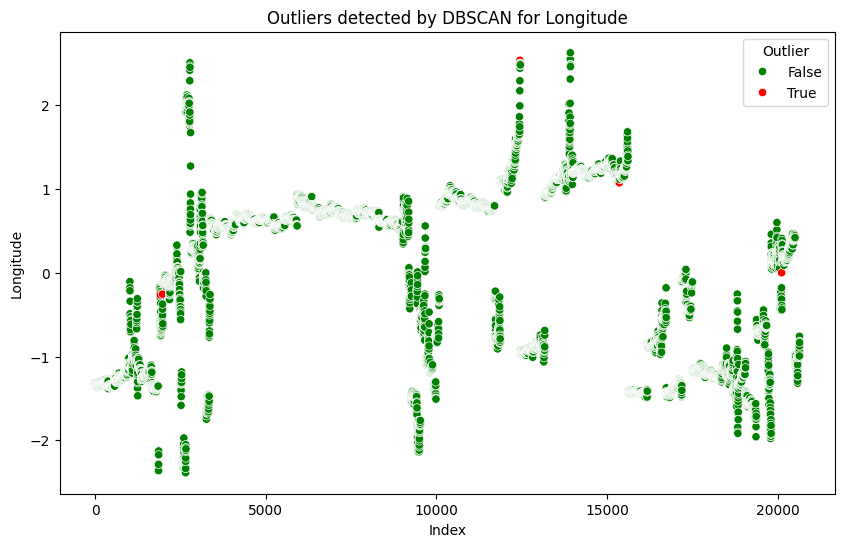

In [25]:
# Function to plot outliers for each method
def plot_outliers(method_name, outliers, X, column):
    plot_data = pd.DataFrame(X, columns=data.columns)
    plot_data['Outlier'] = outliers == -1
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=plot_data.index, y=plot_data[column], hue=plot_data['Outlier'], palette={True: 'red', False: 'green'})
    plt.title(f'Outliers detected by {method_name} for {column}')
    plt.xlabel('Index')
    plt.ylabel(column)
    plt.show()

# Plotting outliers for each method and each column
methods = {
    'Local Outlier Factor': (outliers_lof, X_scaled),
    'DBSCAN': (outliers_dbscan, X_scaled)
}

for method_name, (outliers, X_subset) in methods.items():
    for column in data.columns:
        plot_outliers(method_name, outliers, X_subset, column)

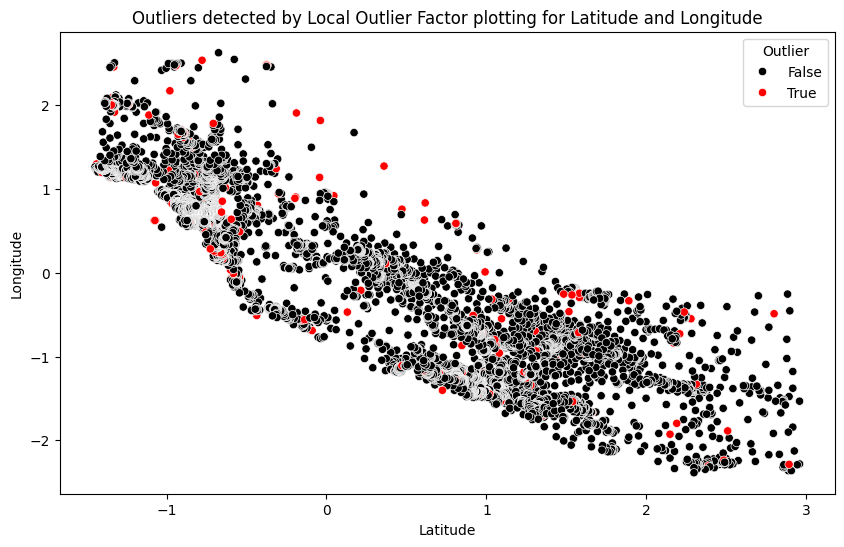

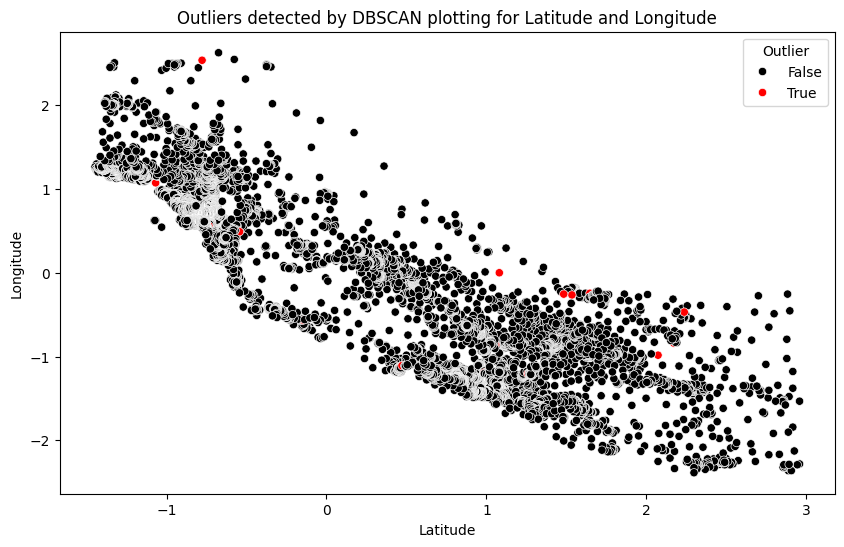

In [26]:
for method_name, (outliers, X_subset) in methods.items():
    plot_data = pd.DataFrame(X_subset, columns=data.columns)
    plot_data['Outlier'] = outliers == -1
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=plot_data['Latitude'], y=plot_data['Longitude'], hue=plot_data['Outlier'], palette={True: 'red', False: 'black'})
    plt.title(f'Outliers detected by {method_name} plotting for Latitude and Longitude')
    plt.xlabel('Latitude')
    plt.ylabel('Longitude')
    plt.show()
 # 0   MedInc      20640 non-null  float64
 # 1   HouseAge    20640 non-null  float64
 # 2   AveRooms    20640 non-null  float64
 # 3   AveBedrms   20640 non-null  float64
 # 4   Population  20640 non-null  float64
 # 5   AveOccup    20640 non-null  float64
 # 6   Latitude    20640 non-null  float64
 # 7   Longitude   20640 non-null  float64